In [ ]:

INPUT_FILE = 'Agri_Data_Cleaned.csv'
print(f"Đang sử dụng dữ liệu từ file: {INPUT_FILE}")


Đang sử dụng dữ liệu từ file: Agri_Train_Combined_16k_clean_column_scaled.csv


### CÁC BIỂU ĐỒ  ĐỂ CHECK CHỈ SỐ P-VALUE


## Bảng Check Đa cộng tuyến

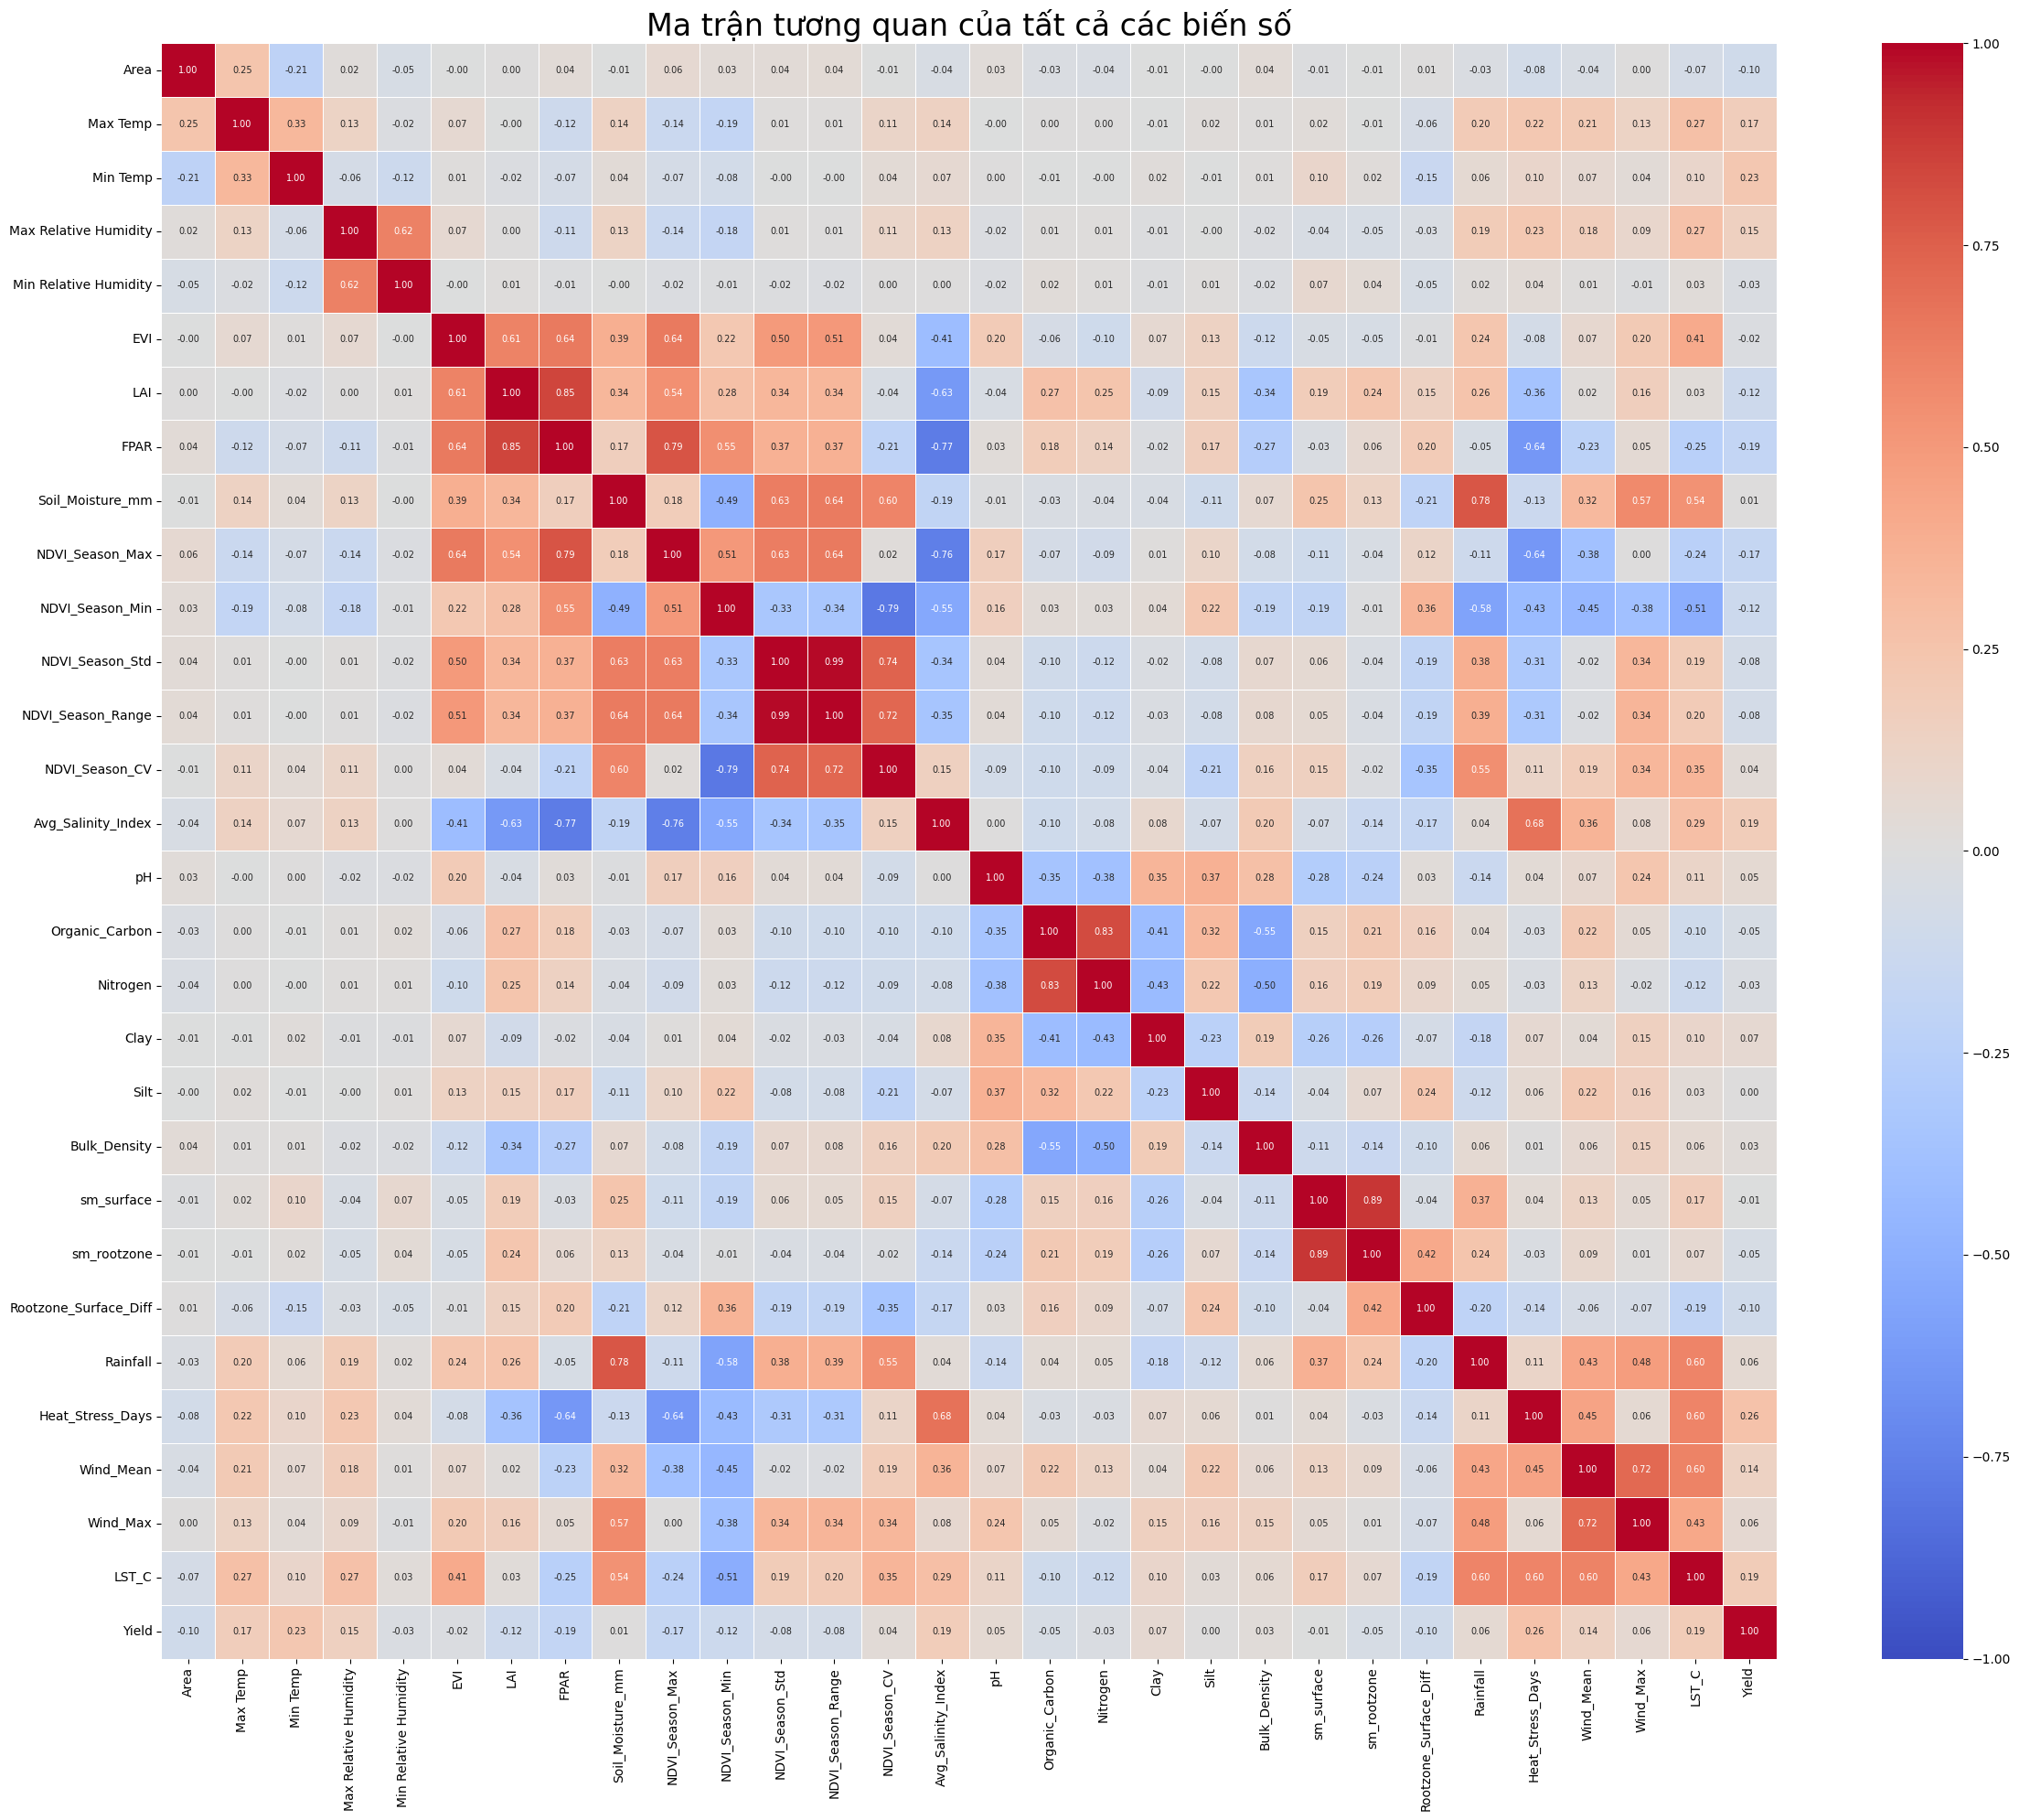

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu từ file CSV
# Bạn hãy thay đường dẫn file của bạn vào đây
file_path = INPUT_FILE 
df = pd.read_csv(file_path)

# 2. Chỉ chọn các cột dữ liệu số (loại bỏ các cột chữ như Tên Tỉnh, Mùa vụ...)
# Vì phép tính tương quan chỉ áp dụng được cho dữ liệu số
df_numeric = df.select_dtypes(include=['number'])

# 3. Tính ma trận tương quan (Correlation Matrix)
corr_matrix = df_numeric.corr()

# 4. Vẽ biểu đồ Heatmap
# Thiết lập kích thước ảnh lớn (25x20 inch) để chứa hết các cột mà không bị đè chữ
plt.figure(figsize=(25, 20))

sns.heatmap(corr_matrix, 
            annot=True,        # Quan trọng: Ghi rõ chỉ số tương quan trong mỗi ô
            fmt=".2f",         # Định dạng số thập phân (2 chữ số sau dấu phẩy)
            cmap='coolwarm',   # Bảng màu: Đỏ (tương quan dương) - Xanh (âm)
            vmin=-1, vmax=1,   # Giới hạn thang màu từ -1 đến 1
            center=0,          # Màu trắng tại giá trị 0 (không tương quan)
            square=True,       # Ép các ô thành hình vuông
            linewidths=0.5,    # Đường viền trắng giữa các ô cho dễ nhìn
            annot_kws={"size": 7}) # Cỡ chữ của số liệu trong ô (nhỏ để vừa ô)

plt.title('Ma trận tương quan của tất cả các biến số', fontsize=24)
plt.xticks(rotation=90, fontsize=10) # Xoay tên cột trục hoành dọc xuống
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout() # Tự động căn chỉnh lề

# 5. Lưu biểu đồ ra file ảnh và hiển thị
plt.show()

# (Tùy chọn) Lưu bảng số liệu thô ra file Excel hoặc CSV để xem chi tiết

C:\Users\AKANEMO\AppData\Local\Temp\ipykernel_22352\3859569295.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="VIF", y="Feature", data=vif_data, palette="viridis")


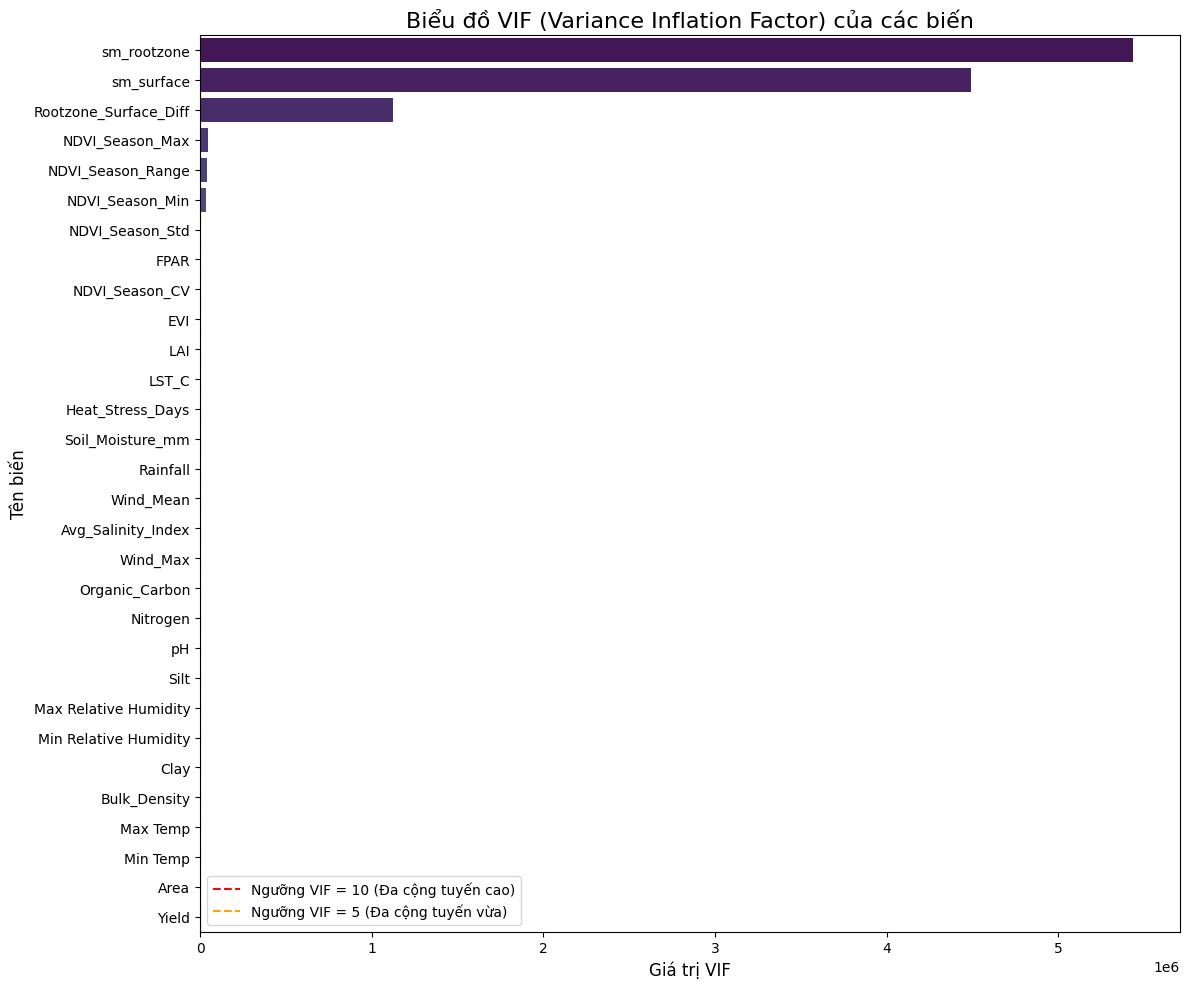

Các biến có VIF cao cần lưu ý:
                  Feature           VIF
23            sm_rootzone  5.436857e+06
22             sm_surface  4.493429e+06
24  Rootzone_Surface_Diff  1.124643e+06
10        NDVI_Season_Max  4.827779e+04
13      NDVI_Season_Range  4.050214e+04
11        NDVI_Season_Min  3.202366e+04
12        NDVI_Season_Std  5.204826e+01
8                    FPAR  2.435635e+01
14         NDVI_Season_CV  1.339110e+01
6                     EVI  1.125438e+01


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Đọc dữ liệu
df = pd.read_csv(INPUT_FILE)

# 2. Xử lý dữ liệu trước khi tính VIF
# Loại bỏ các cột không phải số
df_numeric = df.select_dtypes(include=[np.number])

# Loại bỏ cột 'AP Ratio' vì quá nhiều giá trị thiếu (NaN)
if 'AP Ratio' in df_numeric.columns:
    df_numeric = df_numeric.drop(columns=['AP Ratio'])

# Điền các giá trị thiếu còn lại bằng trung vị (median)
df_numeric = df_numeric.fillna(df_numeric.median())

# Xử lý các giá trị vô cực (nếu có)
df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan).dropna()

# Thêm hằng số (intercept) vào dữ liệu - bước quan trọng để tính VIF chính xác
X = add_constant(df_numeric)

# 3. Tính toán VIF cho từng biến
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

# Tính VIF: vòng lặp qua từng cột
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Loại bỏ dòng hằng số ('const') khỏi kết quả để vẽ biểu đồ
vif_data = vif_data[vif_data["Feature"] != "const"]

# Sắp xếp giảm dần theo giá trị VIF
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# Lưu kết quả ra file CSV để tiện theo dõi

# 4. Vẽ biểu đồ
plt.figure(figsize=(12, 10))
sns.barplot(x="VIF", y="Feature", data=vif_data, palette="viridis")

# Thêm đường ngưỡng cảnh báo
plt.axvline(x=10, color='red', linestyle='--', label='Ngưỡng VIF = 10 (Đa cộng tuyến cao)')
plt.axvline(x=5, color='orange', linestyle='--', label='Ngưỡng VIF = 5 (Đa cộng tuyến vừa)')

plt.title("Biểu đồ VIF (Variance Inflation Factor) của các biến", fontsize=16)
plt.xlabel("Giá trị VIF", fontsize=12)
plt.ylabel("Tên biến", fontsize=12)
plt.legend()
plt.tight_layout()

# Lưu và hiển thị biểu đồ
plt.show()

# In ra các biến có VIF cực cao (VIF > 10)
print("Các biến có VIF cao cần lưu ý:")
print(vif_data[vif_data["VIF"] > 10])

## Kiểm tra Phân phối của biến

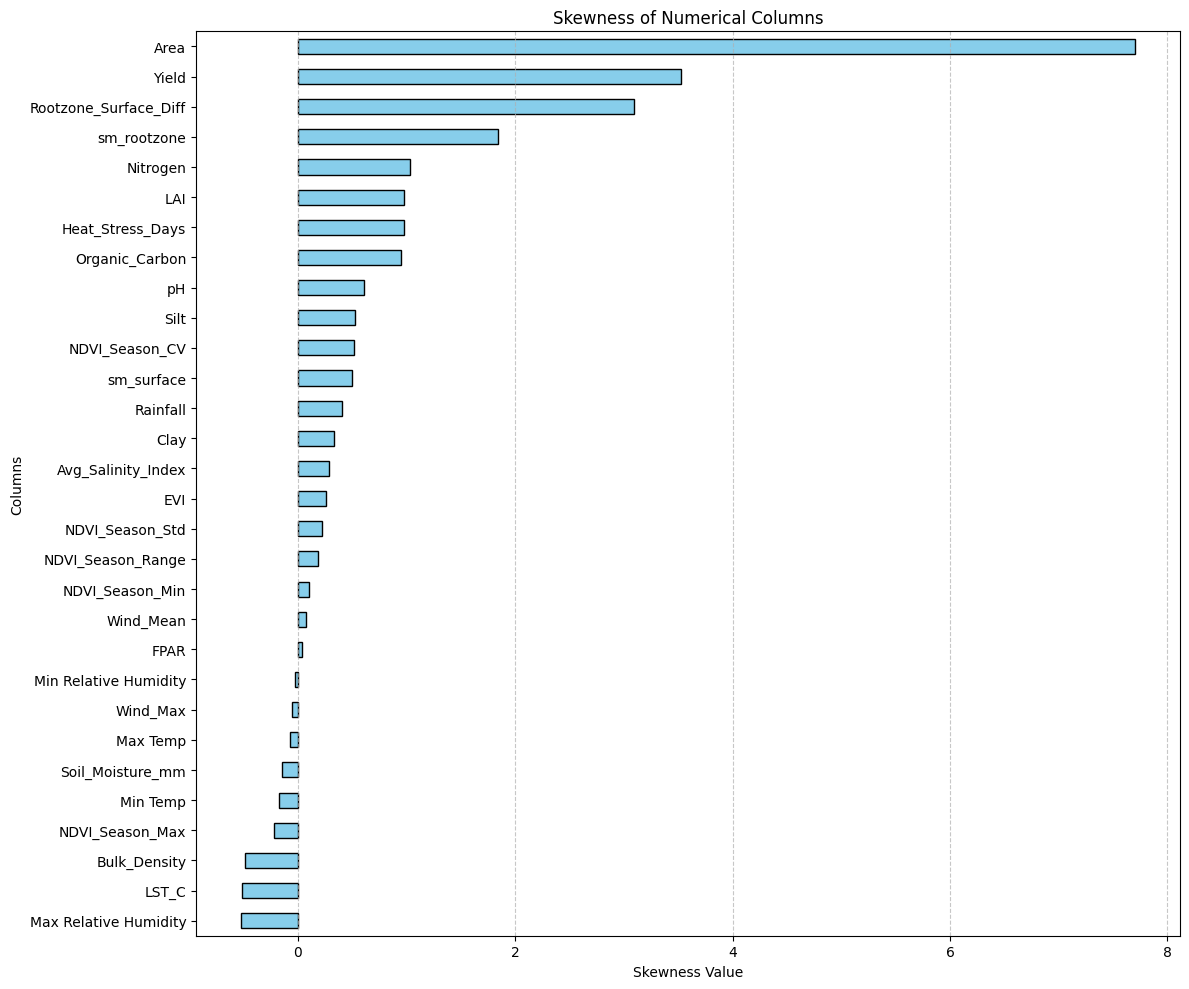

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv(INPUT_FILE)

# Chọn các cột số
numerical_cols = df.select_dtypes(include=['number'])

# Tính độ lệch (skewness)
skewness = numerical_cols.skew().sort_values()

# Vẽ biểu đồ
plt.figure(figsize=(12, 10))
skewness.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Skewness of Numerical Columns')
plt.xlabel('Skewness Value')
plt.ylabel('Columns')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Lưu biểu đồ
plt.show()

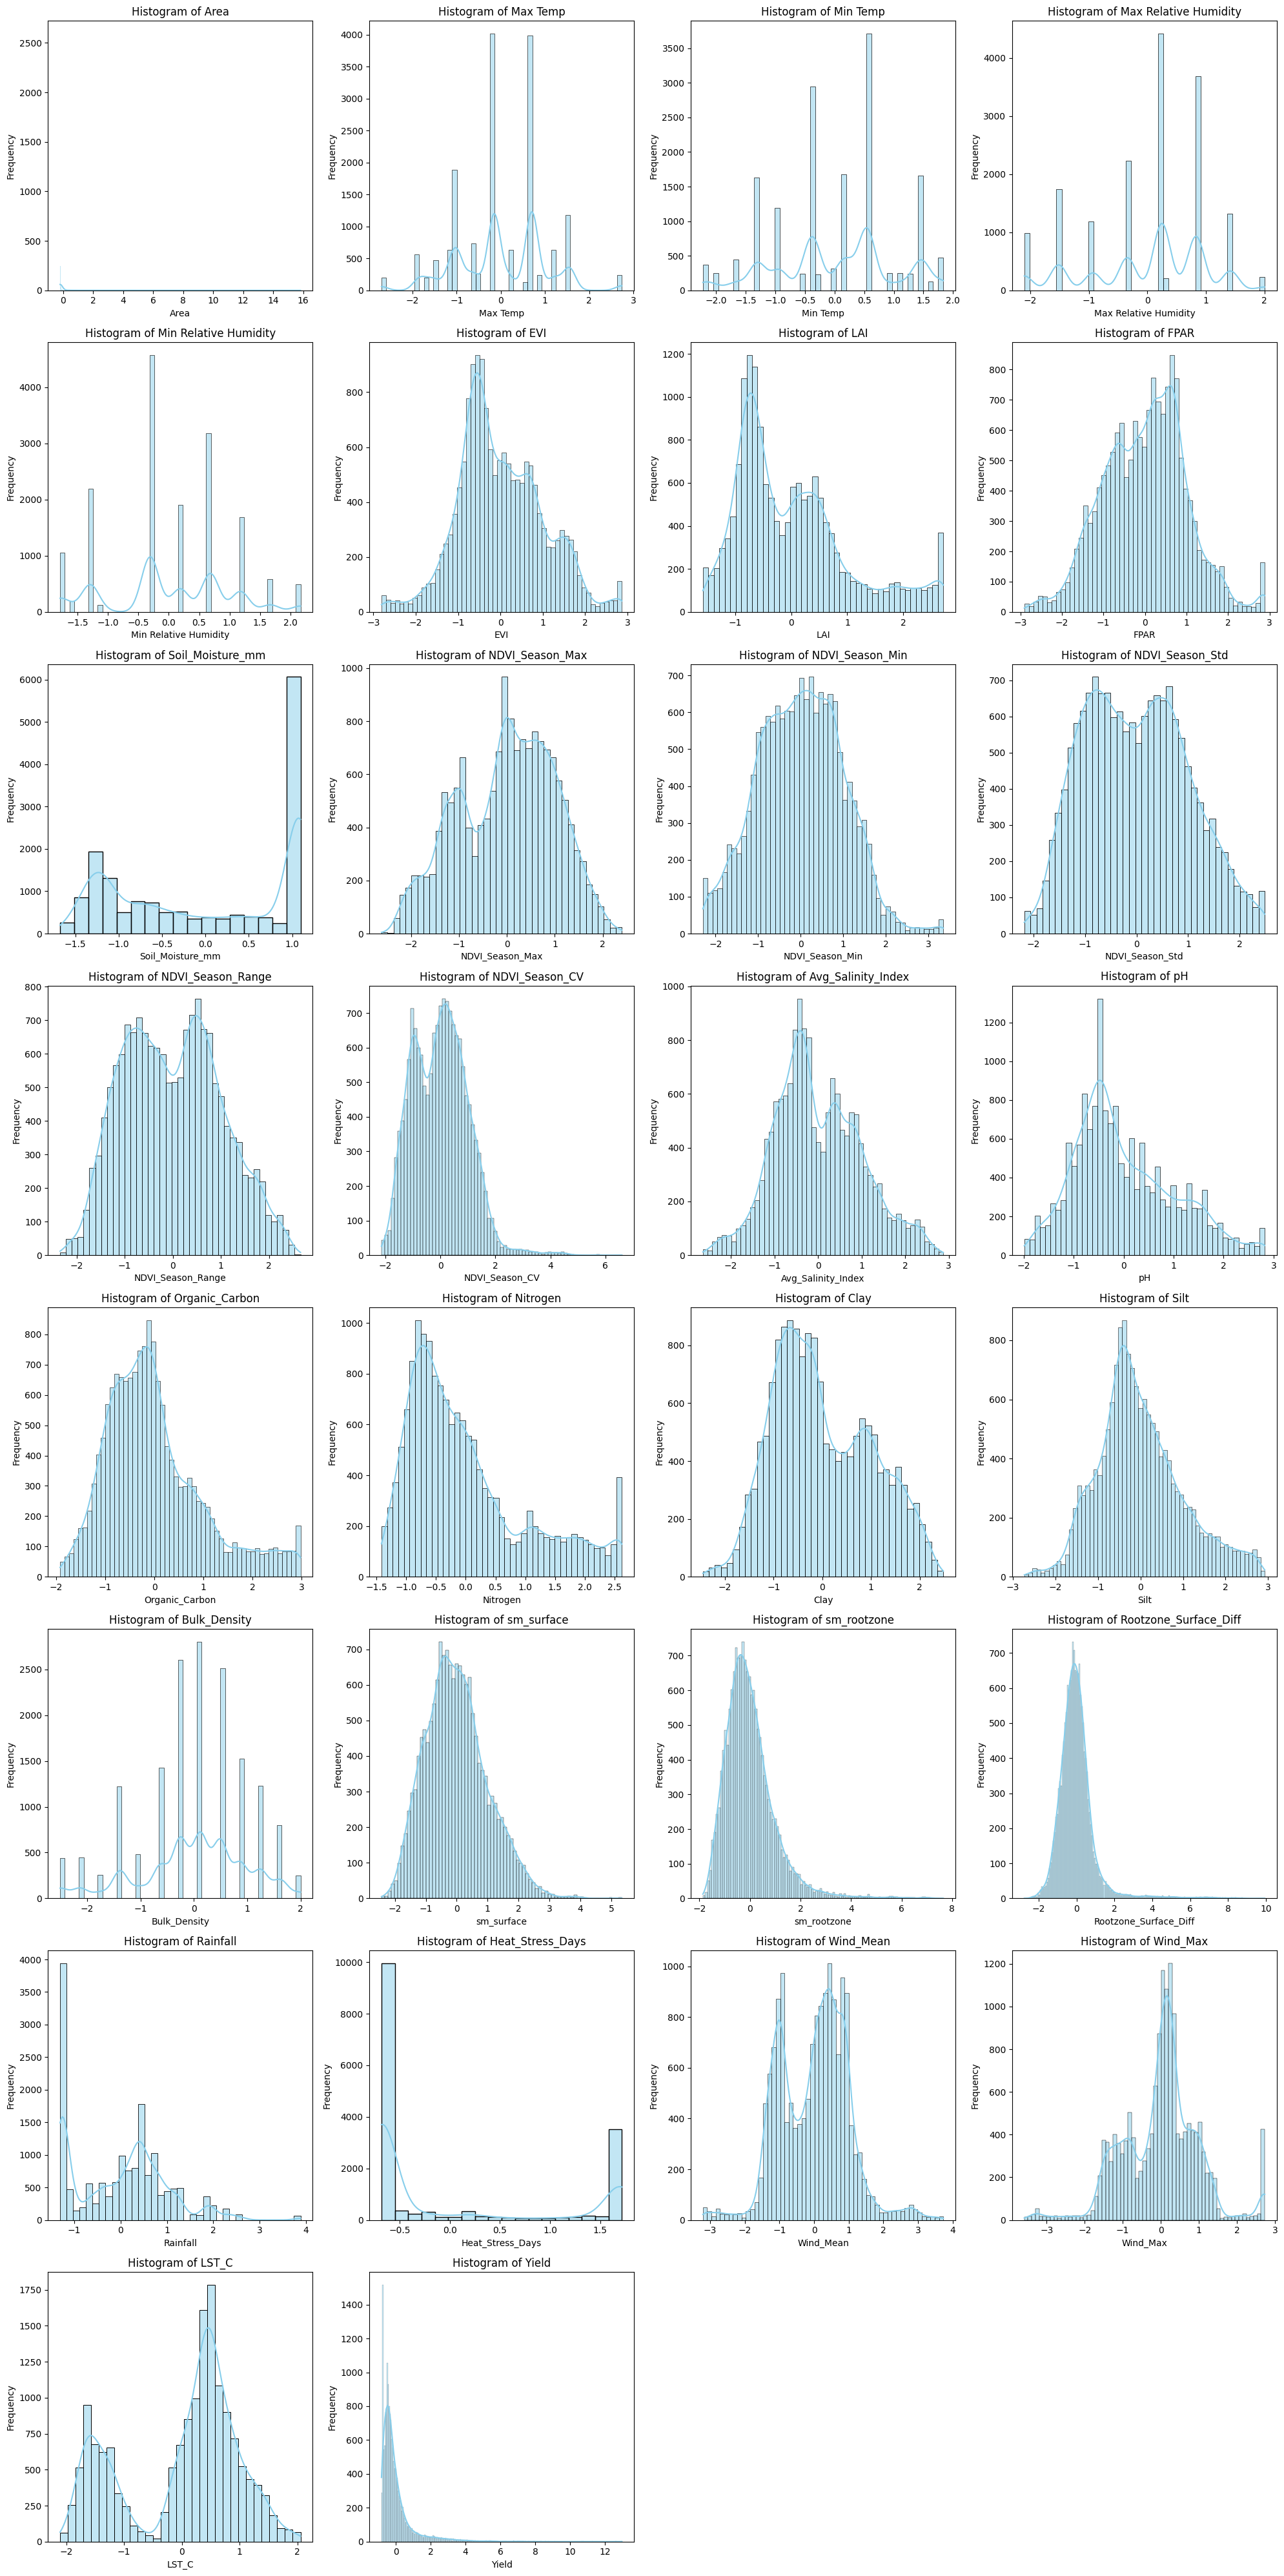

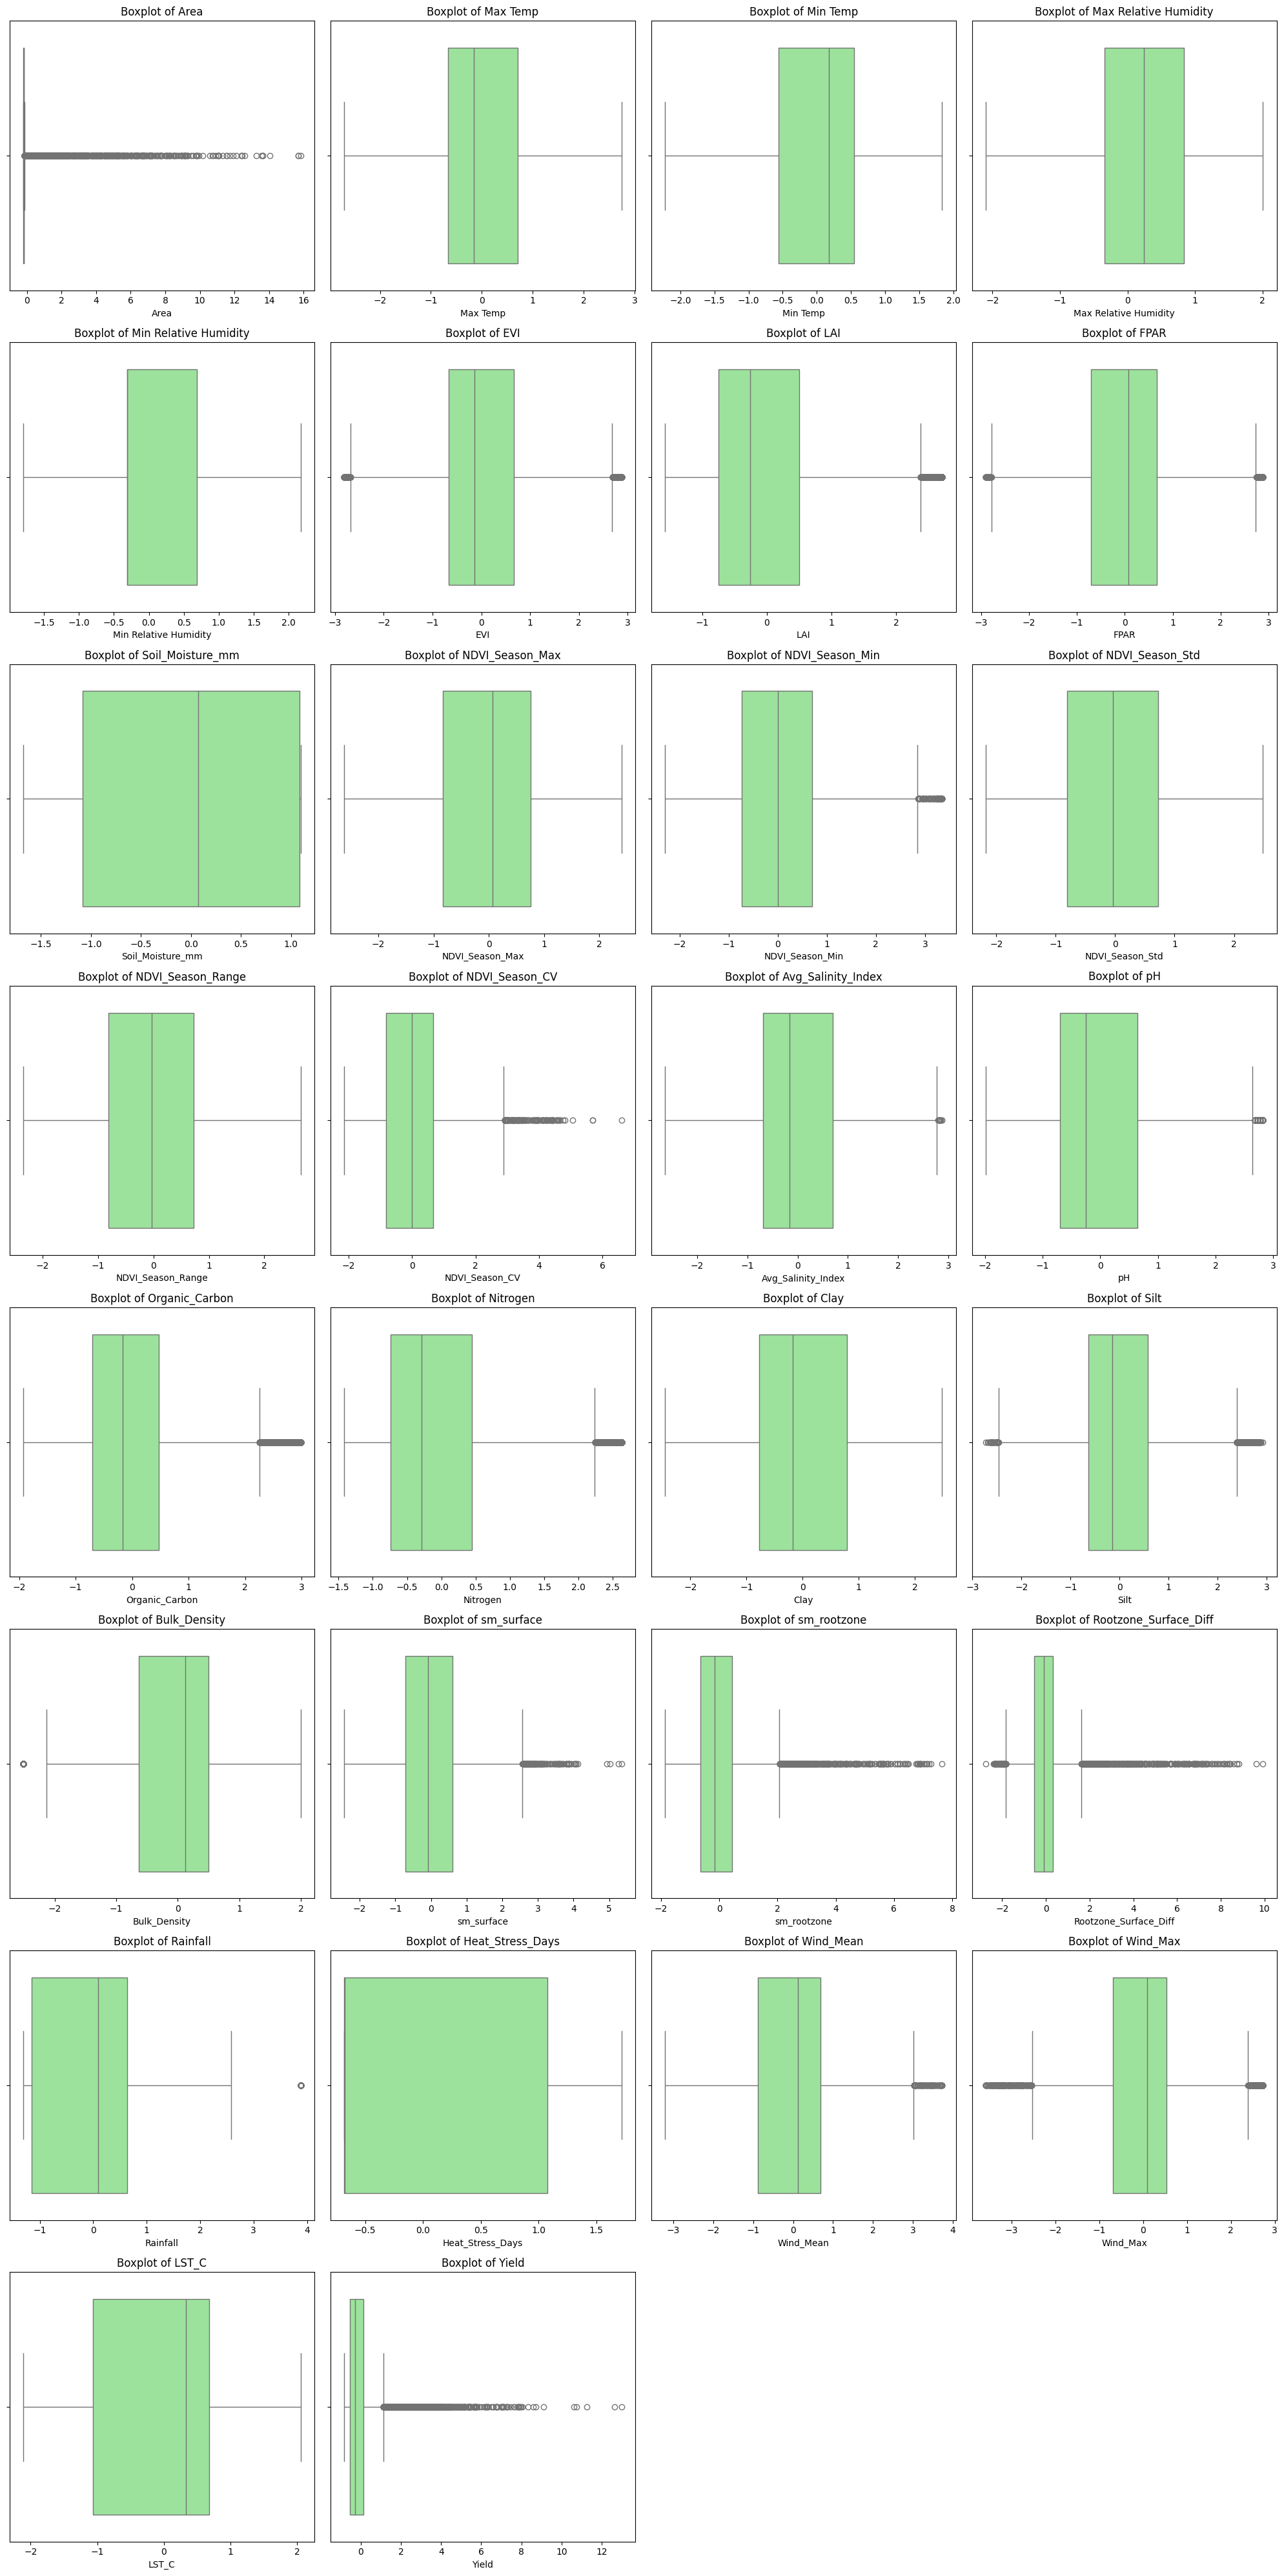

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Đọc dữ liệu
df = pd.read_csv(INPUT_FILE)

# Chọn các cột số
numerical_cols = df.select_dtypes(include=['number']).columns
num_cols_count = len(numerical_cols)

# Thiết lập lưới hiển thị
n_cols = 4  # Số cột trên mỗi hàng
n_rows = math.ceil(num_cols_count / n_cols)

# --- Vẽ Histogram ---
plt.figure(figsize=(20, 5 * n_rows))  # Tự động điều chỉnh chiều cao
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show() # Hiển thị trực tiếp trong Jupyter

# --- Vẽ Boxplot ---
plt.figure(figsize=(20, 5 * n_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show() # Hiển thị trực tiếp trong Jupyter